In [5]:
HPDv3_dict = {
    256 : {
        "PickScore": 21.03,
        "HPSv3": 7.24,
        "DeQA": 3.87,
        "Aesthetic": 5.68
    },
    512 : {
        "PickScore": 21.04,
        "HPSv3": 7.33,
        "DeQA": 3.96,
        "Aesthetic": 5.64
    },
    768 : {
        "PickScore": 21.04,
        "HPSv3": 7.23,
        "DeQA": 4.02,
        "Aesthetic": 5.64
    },
    1024 : {
        "PickScore": 21.00,
        "HPSv3": 7.07,
        "DeQA": 3.97,
        "Aesthetic": 5.61
    }
}

Civitai_dict = {
    256 : {
        "PickScore": 21.57,
        "HPSv3": 8.71,
        "DeQA": 3.96,
        "Aesthetic": 5.94
    },
    512 : {
        "PickScore": 21.57,
        "HPSv3": 8.67,
        "DeQA": 4.01,
        "Aesthetic": 5.96
    },
    768 : {
        "PickScore": 21.50,
        "HPSv3": 8.45,
        "DeQA": 4.02,
        "Aesthetic": 5.89
    },
    1024 : {
        "PickScore": 21.57,
        "HPSv3": 8.57,
        "DeQA": 4.08,
        "Aesthetic": 5.94
    }
}

dataset_size_list = [ 256, 512, 768, 1024 ]
reward_model_list = [ "PickScore", "HPSv3", "DeQA", "Aesthetic" ]



In [6]:

import matplotlib.pyplot as plt
import numpy as np

# ### v1
# HPDv3_color = '#FF7F00'
# Civitai_color = '#377EB8'
# ### v2
# HPDv3_color = '#6f9ec8'
# Civitai_color = '#fca86a'
### v3
HPDv3_color = '#FF7F00' # "#F08513" # "#F3912C"# "#F2901C"# '#EE8227'
Civitai_color = '#79ADD6'

line_width = 4
marker_size = 10
legend_size = 12
tick_size = 12
label_size = 16

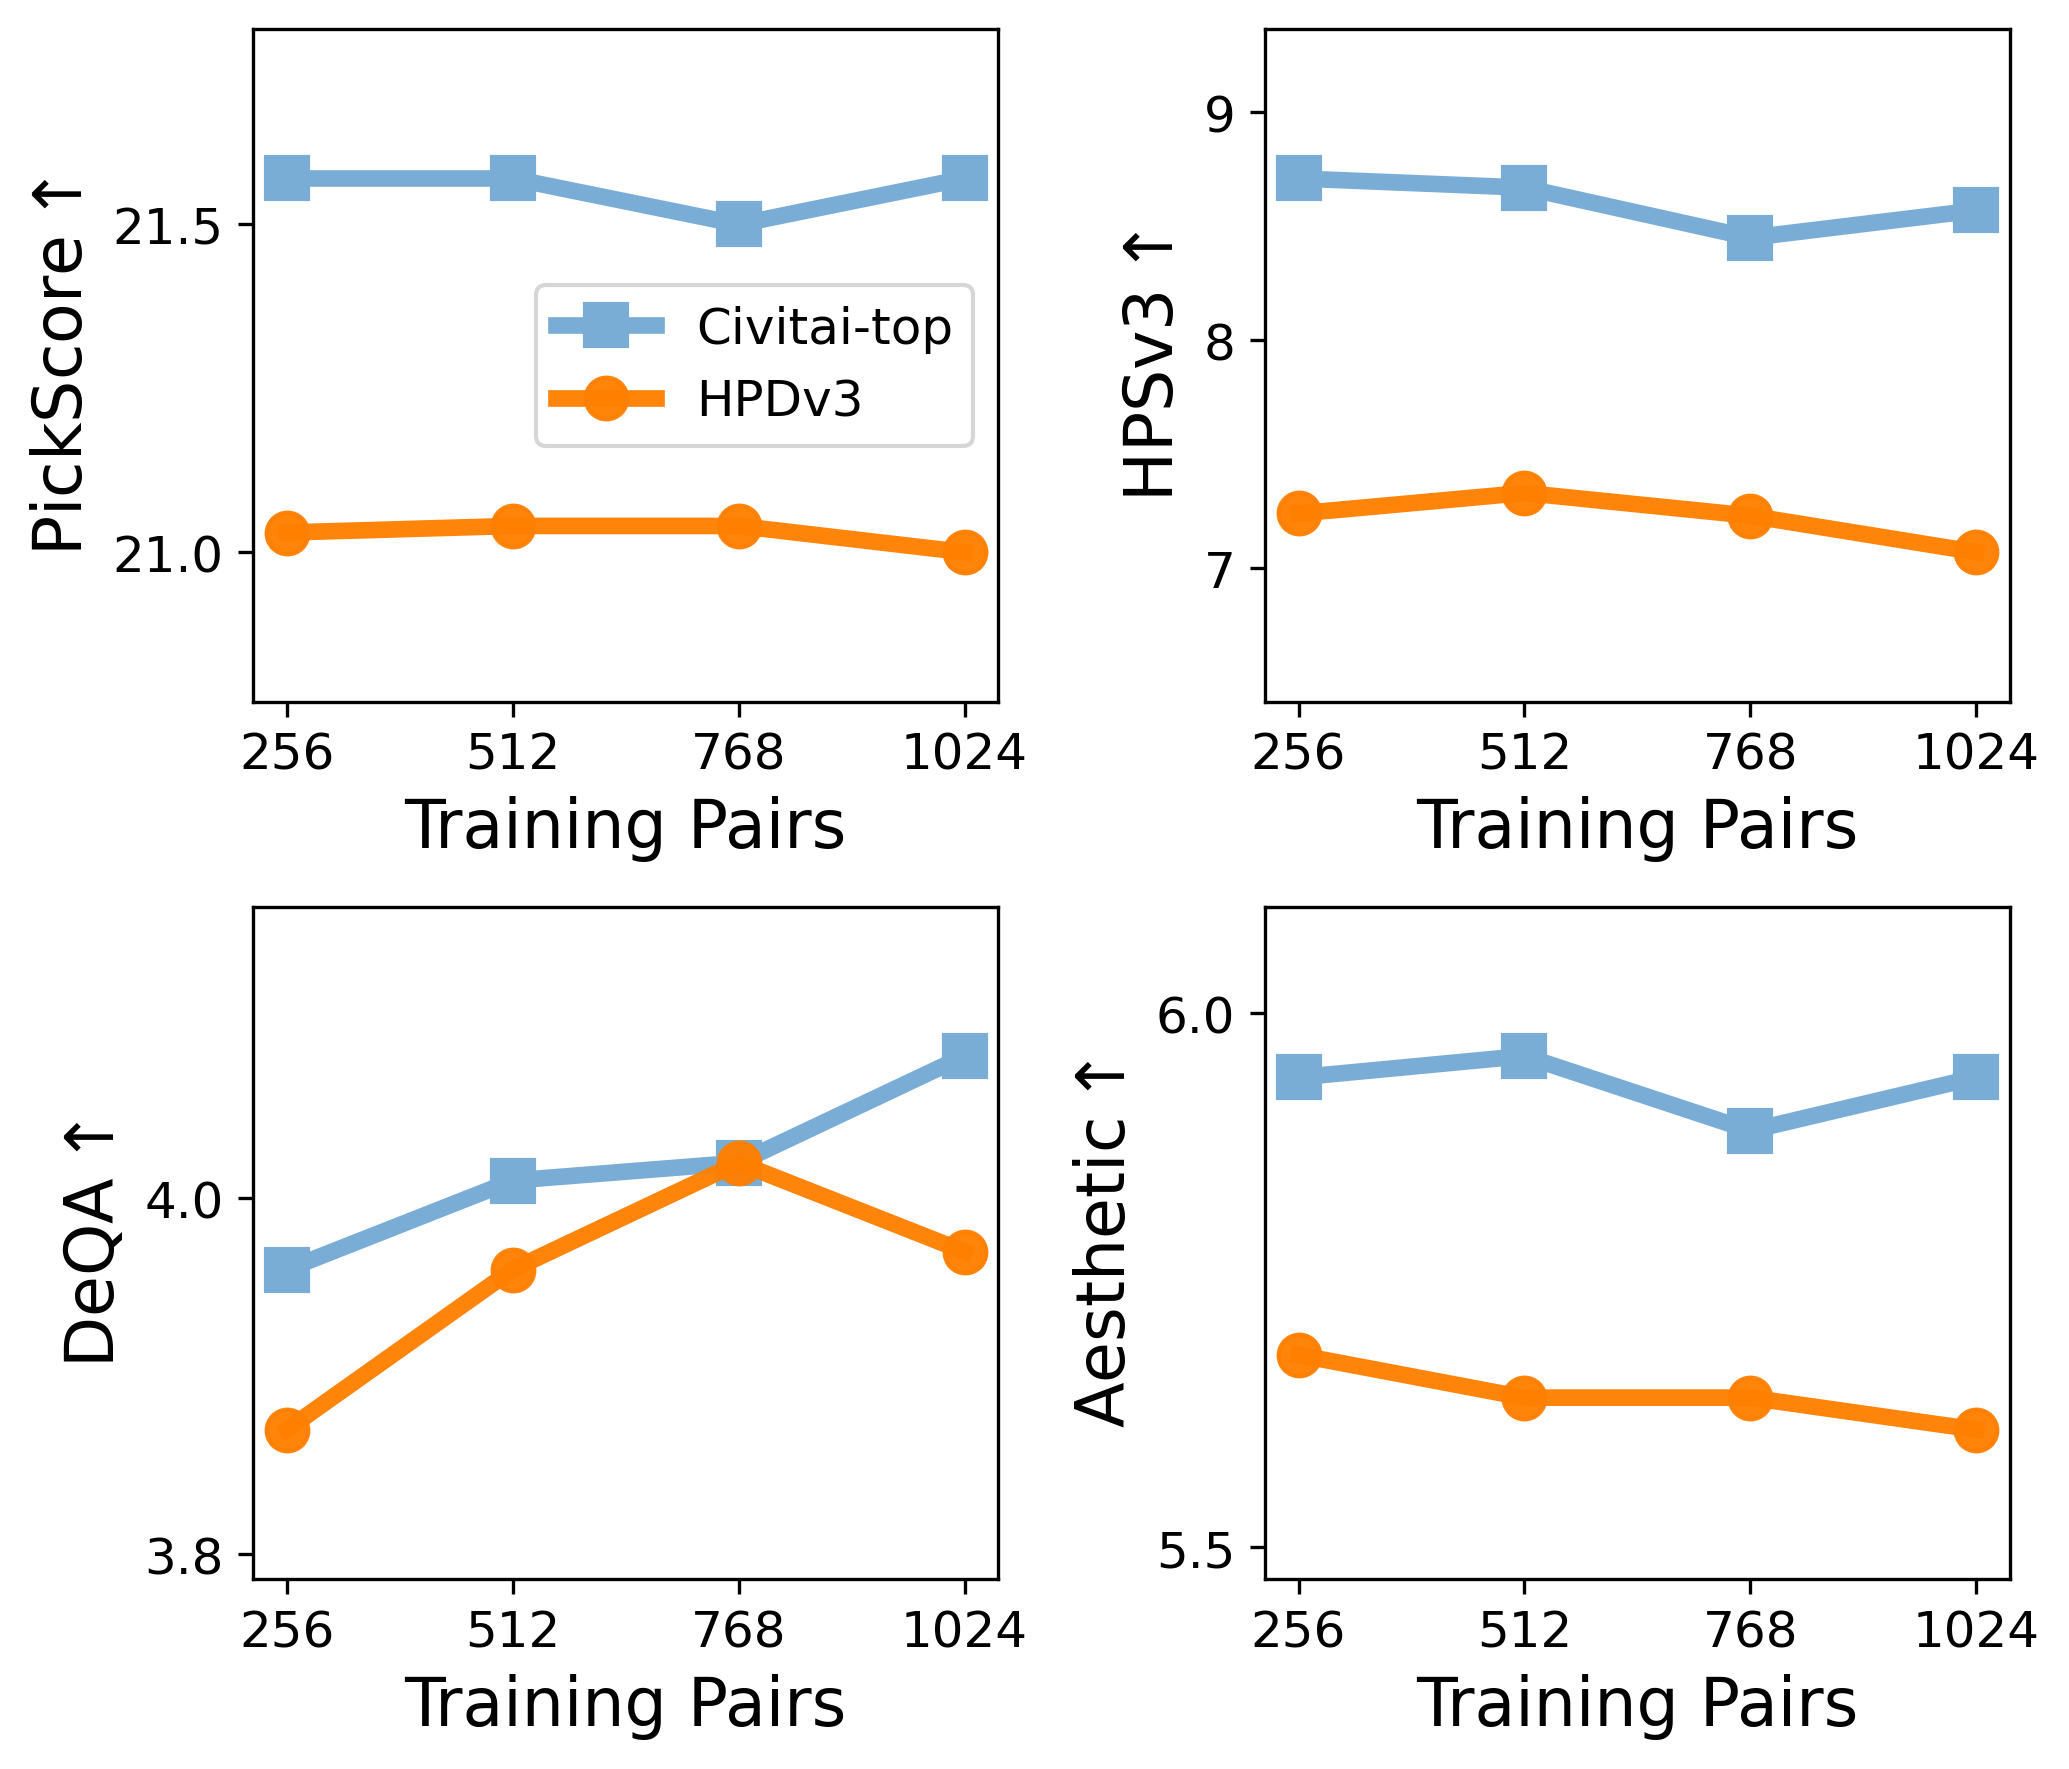

In [9]:
# 为每个reward model绘制折线图
# fig, axes = plt.subplots(1, 4, figsize=(12, 3), dpi=200)
fig, axes = plt.subplots(2, 2, figsize=(7, 6), dpi=300)

for idx, reward_model in enumerate(reward_model_list):
    ax = axes.flat[idx]
    
    hpdv3_values = [HPDv3_dict[size][reward_model] for size in dataset_size_list]
    civitai_values = [Civitai_dict[size][reward_model] for size in dataset_size_list]
    
    # 绘制折线
    ax.plot(dataset_size_list, civitai_values, marker='s', linewidth=line_width, markersize=marker_size, 
            label='Civitai-top', color=Civitai_color)
    ax.plot(dataset_size_list, hpdv3_values, marker='o', linewidth=line_width, markersize=marker_size, 
            label='HPDv3', color=HPDv3_color, alpha=0.96)
    
    # 设置标签
    ax.set_xlabel('Training Pairs', fontsize=label_size)
    ax.set_ylabel(rf'{reward_model}$\uparrow$', fontsize=label_size)
    # 只在第一张子图显示图例
    if idx == 0:
        ax.legend(loc='best', fontsize=legend_size)
        
    # ax.grid(True, alpha=0.3, linestyle='--')
    
    # 设置x轴刻度
    ax.set_xticks(dataset_size_list)
    ax.tick_params(axis='both', labelsize=tick_size)
    
    # 自动调整y轴范围，减少空白区域
    all_values = hpdv3_values + civitai_values
    y_min, y_max = min(all_values), max(all_values)
    y_margin = (y_max - y_min) * 0.4  # 留40%的边距
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    # 设置y轴为2个刻度
    ax.locator_params(axis='y', nbins=2)
    
plt.tight_layout()
plt.savefig('2026-ICML-ablation_pairs_num.pdf', dpi=300, bbox_inches='tight')
plt.show()